# The Ocean's Deep-Diving Animals


How deep can air-breathing animals dive into the ocean? Do whales go deeper than seals? Which animals go the deepest?

In this project, we'll harness the powerful of data visualization to compare the diving depths of the ocean's deepest divers. Along the way, we'll transform Matplotlib's default bar charts into compelling visuals that tell a story.

### Loading the Data

The main file for this project is `deepest-diving-animals.csv`. This contains the deepest diving depths ever recorded in the scientific literature for different species of marine animals (measured in meters).


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

divers = pd.read_csv('deepest-diving-animals.csv')
divers

,animal,category,depth
0,Emperor Penguin,penguins,564
1,King Penguin,penguins,343
2,Rockhopper Penguin,penguins,104
3,Macaroni Penguin,penguins,154
4,Royal Penguin,penguins,226
...,...,...,...
113,Northern Sea Otter,sea otters,97
114,Southern Sea Otter,sea otters,88
115,Atlantic Walrus,walruses,500
116,Dugong,other marine mammals,33


This dataset contains the deepest recorded depths for 118 animals across a variety of categories.


Let's perform a quick `value_counts()` to list how many animals are in each category.



In [23]:
divers['category'].value_counts()

category
other seabirds          45
seals                   24
penguins                14
toothed whales          14
baleen whales            7
sea lions                5
turtles                  4
sea otters               2
other marine mammals     2
walruses                 1
Name: count, dtype: int64

This shows that there are 10 different categories, including 14 species of penguins and 7 species of baleen whales.

Let's find the deepest depth that animals can dive for each of these 10 categories.

### Max Depth per Category


In [ ]:
max_depths = divers.groupby('category')['depth'].max()
max_depths

category
baleen whales            616
other marine mammals      33
other seabirds           152
penguins                 564
sea lions                597
sea otters                97
seals                   2389
toothed whales          2992
turtles                 1344
walruses                 500
Name: depth, dtype: int64

Here max_depths is a series object. The values are indexed by category.



In [ ]:
df = max_depths.reset_index(name='max_depth')
df 

,category,max_depth
0,baleen whales,616
1,other marine mammals,33
2,other seabirds,152
3,penguins,564
4,sea lions,597
5,sea otters,97
6,seals,2389
7,toothed whales,2992
8,turtles,1344
9,walruses,500


From this dataframe we see that there are penguins that can dive down to 564 meters! This is much deeper than other seabirds which have a maximum recorded depth of 152 meters.

### The Default Bar Chart

Let's visualize these maximum diving depths using a bar chart. We'll start with Matplotlib's default settings.


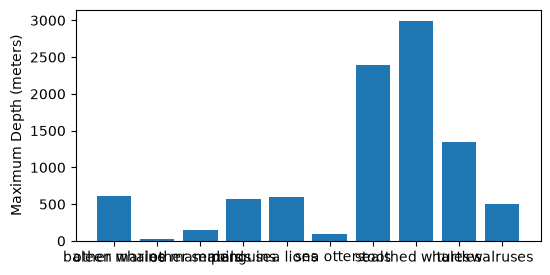

In [26]:
plt.figure(figsize=(6, 3))
plt.bar(df['category'], df['max_depth'])
plt.ylabel('Maximum Depth (meters)')
plt.show()

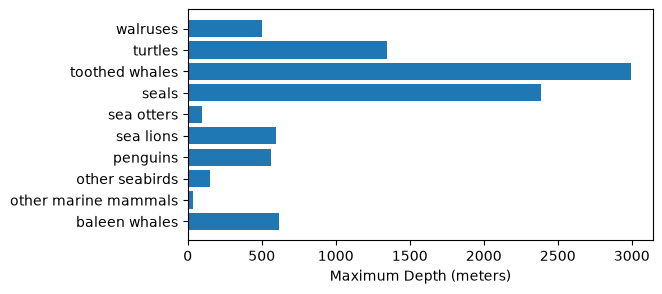

In [27]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')
plt.show()


In [ ]:
df = df.sort_values('max_depth')
df 

,category,max_depth
1,other marine mammals,33
5,sea otters,97
2,other seabirds,152
9,walruses,500
3,penguins,564
4,sea lions,597
0,baleen whales,616
8,turtles,1344
6,seals,2389
7,toothed whales,2992


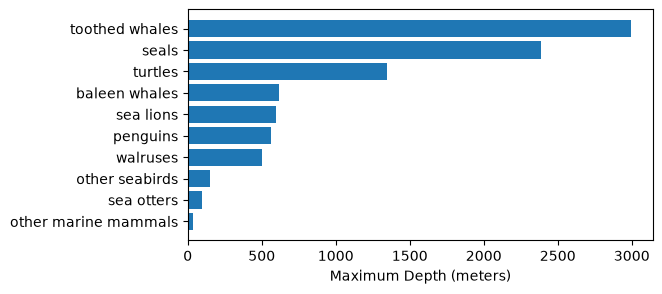

In [29]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')
plt.show()

Sorting by depth makes it easier to compare the diving depths of different animal categories.


The default chart is trapped in bounding lines called spines.

Let's hide the spines to produce a cleaner graph:

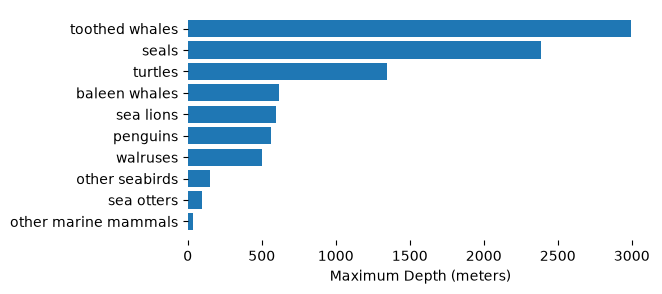

In [30]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')

# Pro Tip 3
ax = plt.gca()
ax.spines[['top','bottom','left','right']].set_visible(False)

plt.show()

Next let's replace the ticks with vertical grid lines.

We can fade the grid lines by reducing the alpha level to 50%:

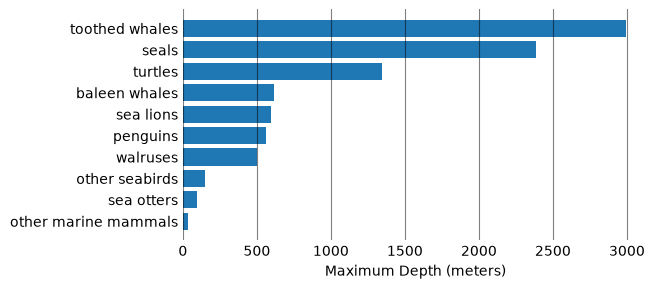

In [ ]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')

ax = plt.gca() 
ax.spines[['top','bottom','left','right']].set_visible(False)
ax.grid(axis='x', color='black', alpha=0.5)
ax.tick_params(axis='both', length=0)
plt.show()

There we go! We swapped out the "ticks and spines" for "faded grid lines".

This produces a less cluttered presentation of the data. The vertical grid makes it easier to estimate the value of the horizontal bars.


In [ ]:
def clean_bar_axes( ):
	ax = plt.gca()
	ax.spines[['top','bottom','left','right']].set_visible(False)
	ax.grid(axis='x', color='black', alpha=0.5)
	ax.tick_params(axis='both', length=0)

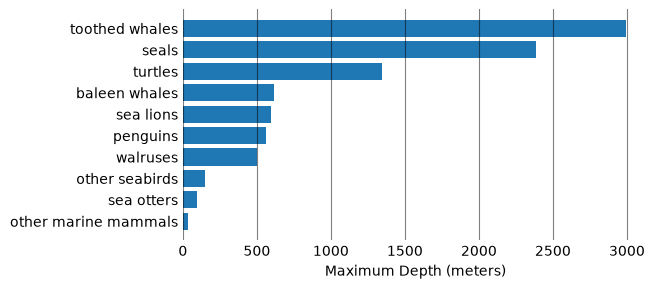

In [33]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'])
plt.xlabel('Maximum Depth (meters)')
clean_bar_axes()

How extreme is 2000 meters under the ocean?

We can enhance the storytelling of this graph by helping the reader build intuition about these depth values. In this case, maybe we can give a sense of the intense pressures these deep-diving animals experience.

There is a well-documented case of a nuclear submarine that imploded when it descended to the crushing depths of 730 meters.

Let's add this submarine implosion depth as a reference bar to our graph, and use a different color to distinguish it from the other data.

### Adding a Reference Row
A flexible way to control the colors in a graph is to first add a color column to the dataframe. 

In [40]:
df['color'] = 'C0'
df 

,category,max_depth,color
1,other marine mammals,33,C0
5,sea otters,97,C0
2,other seabirds,152,C0
9,walruses,500,C0
3,penguins,564,C0
4,sea lions,597,C0
0,baleen whales,616,C0
ref_0,submarine implosion,730,C0
8,turtles,1344,C0
6,seals,2389,C0


This created a new `color` column with values of `C0`.

`C0` is the first color in the tab10 color palette supported by Matplotlib.

Now let's add a reference row for the "submarine implosion" depth of 730 meters. We'll use a color of `C1`.



In [ ]:
df.loc['ref_0'] = ['submarine implosion', 730, 'C1']
df = df.sort_values('max_depth')
df 

,category,max_depth,color
1,other marine mammals,33,C0
5,sea otters,97,C0
2,other seabirds,152,C0
9,walruses,500,C0
3,penguins,564,C0
4,sea lions,597,C0
0,baleen whales,616,C0
ref_0,submarine implosion,730,C1
8,turtles,1344,C0
6,seals,2389,C0


This shows that there are only 3 categories that go deeper than our reference depth.

### Plotting with Color



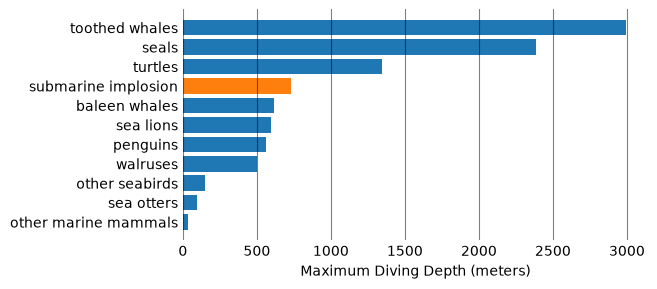

In [36]:
plt.figure(figsize=(6, 3))
plt.barh(df['category'], df['max_depth'], color=df['color'])
plt.xlabel('Maximum Diving Depth (meters)')
clean_bar_axes()


## Project extensions



### Diving Depths of Penguins

Let's apply our visualization techniques to a specific group of animals, such as penguins. We will filter the `divers` dataset to include only penguins, sort them by their maximum diving depth, and then create a horizontal bar chart to visualize these depths.

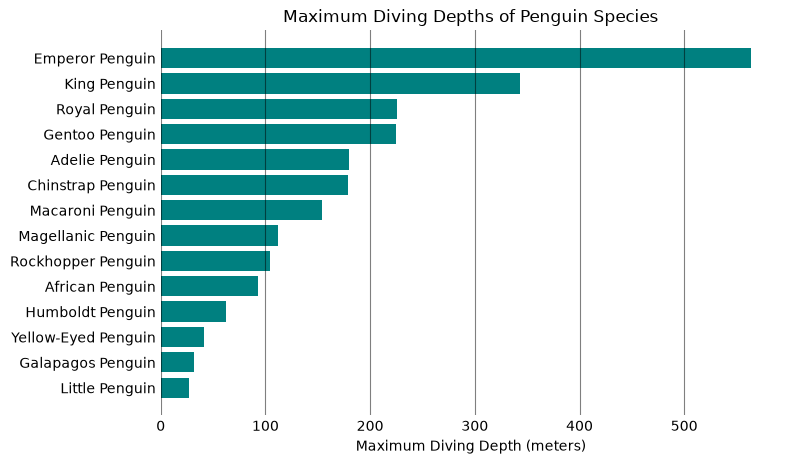

,animal,category,depth
0,Emperor Penguin,penguins,564
1,King Penguin,penguins,343
4,Royal Penguin,penguins,226
9,Gentoo Penguin,penguins,225
7,Adelie Penguin,penguins,180
8,Chinstrap Penguin,penguins,179
3,Macaroni Penguin,penguins,154
12,Magellanic Penguin,penguins,112
2,Rockhopper Penguin,penguins,104
10,African Penguin,penguins,93


In [ ]:
penguins_df = divers[divers['category'] == 'penguins'].sort_values('depth', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(penguins_df['animal'], penguins_df['depth'], color='teal')
plt.xlabel('Maximum Diving Depth (meters)')
plt.title('Maximum Diving Depths of Penguin Species')

clean_bar_axes()

plt.gca().invert_yaxis()
plt.show()

penguins_df

This chart clearly illustrates the varying diving capabilities among different penguin species. The Emperor Penguin stands out as the deepest diver in this group, reaching depths significantly greater than other species like the King Penguin and Macaroni Penguin. By sorting the data and using a horizontal bar chart, we can easily compare these depths and identify the species with the most impressive diving abilities within the penguin category.

### Deep-Sea Divers (Exceeding 1,000 meters) with Reference

Next, let's explore animals that dive into the 'midnight zone' (depths exceeding 1,000 meters). We'll also incorporate a new reference point: the Titanic's resting depth (approximately 3,800 meters), to provide additional context to these extreme depths. We will again use color to highlight this reference.

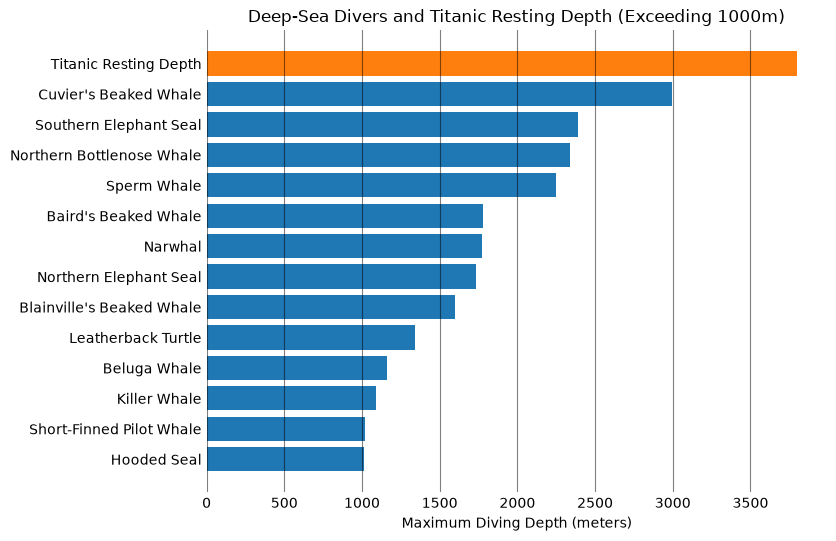

,animal,category,depth,color
68,Hooded Seal,seals,1016,C0
94,Short-Finned Pilot Whale,toothed whales,1019,C0
100,Killer Whale,toothed whales,1087,C0
93,Beluga Whale,toothed whales,1160,C0
90,Leatherback Turtle,turtles,1344,C0
97,Blainville's Beaked Whale,toothed whales,1599,C0
74,Northern Elephant Seal,seals,1735,C0
98,Narwhal,toothed whales,1773,C0
92,Baird's Beaked Whale,toothed whales,1777,C0
102,Sperm Whale,toothed whales,2250,C0


In [43]:

deep_divers_df = divers[divers['depth'] >= 1000].copy()


deep_divers_df['color'] = 'C0'



deep_divers_df.loc['ref_titanic'] = ['Titanic Resting Depth', 'reference', 3800, 'C1']


deep_divers_df = deep_divers_df.sort_values('depth')


plt.figure(figsize=(8, 6))
plt.barh(deep_divers_df['animal'], deep_divers_df['depth'], color=deep_divers_df['color'])
plt.xlabel('Maximum Diving Depth (meters)')
plt.title('Deep-Sea Divers and Titanic Resting Depth (Exceeding 1000m)')


clean_bar_axes()

plt.show()

deep_divers_df

This visualization brings into focus the truly extreme depths reached by some marine animals. The toothed whales, seals, and turtles are remarkable in their ability to survive and operate at depths far exceeding the 1,000-meter mark. The inclusion of the Titanic's resting depth (3,800 meters) serves as a stark reference point, highlighting just how profound the diving capabilities of the toothed whales are, as they approach and even exceed such iconic depths.

### Conclusion

This project embarked on a journey to visualize and understand the remarkable diving depths of various marine animals. We started by loading and inspecting the data, then calculated the maximum diving depth for each animal category.

Throughout the project, we meticulously applied **"Pro Tips" for compelling bar charts**:

1.  **Using horizontal bars:** This significantly improved readability by preventing overlapping labels.
2.  **Ordering the bars:** Sorting by depth provided a clear visual hierarchy, making comparisons more intuitive.
3.  **Swapping ticks and spines for faded grid lines:** This cleaned up the aesthetic, making the data stand out without unnecessary visual clutter.

We further enhanced our storytelling by introducing **meaningful reference bars**. Initially, we used the "submarine implosion" depth to contextualize the extreme pressures at certain depths. We extended this by examining specific groups, such as penguins, and explored the truly **deep-sea divers (exceeding 1,000 meters)**, using the "Titanic's resting depth" as another powerful reference point. This allowed us to highlight that toothed whales, in particular, dive to astonishing depths, rivaling or even surpassing the location of historical shipwrecks.

In summary, by combining data manipulation with thoughtful visualization techniques, we transformed raw depth data into clear and compelling narratives about the ocean's deepest-diving inhabitants.